## 🧪 Experimental Setup and Purpose

### Objective

The goal of this experiment is to compare the predictive accuracy of several regression models on the NYC Airbnb listings dataset. We evaluate a range of models, from global baselines (Linear Regression, Polynomial Ridge) and standard non-parametric methods (k-Nearest Neighbors) to specialized local regression models.

The primary purpose is to **demonstrate the value of a generalized, context-aware kernel** for local regression. We aim to show that by encoding rich, multi-modal information, in this case, both standard listing features and subway network topology, we can build a model that is significantly more accurate than models that treat "locality" as a simple, single-metric concept.

### The Problem with Traditional Locality

Traditional local models like k-NN and standard Local Polynomial Regression (LPR) define a "neighborhood" using a single, monolithic distance metric (e.g., Euclidean or Haversine distance). This is a severe limitation for complex, real-world data.

For example, in real estate:
* A listing 500 meters away **across a highway or river** is not truly "close."
* A listing 2km away but **on the same express subway line** might be functionally "closer" for a tourist or commuter than one 800m away that requires a bus transfer.

Standard models using only latitude and longitude as features cannot capture this nuanced, network-based definition of proximity.

### Our Proposed Model: Generalized Robust Context-Aware LPR

To demonstrate on this particular dataset, we introduce the **`GRC-LPR Subway`** model. This model is a practical implementation of the **Generalized Robust Context-Aware LPR (GRC-LPR)** framework.

This framework improves on standard LPR in three key ways:

1.  **Context-Awareness (The Key Improvement):** It decomposes the main predictor kernel $\mathcal{K}_P$ into a *product* of multiple component kernels. This allows us to fuse different "contexts" together.
2.  **Robustness (from RSKLPR):** It is inherently robust to outliers in the *price* (the $Y$-variable). It does this by using a bilateral-filter-like kernel that down-weights listings with anomalous prices, even if they are close in feature-space.
3.  **Kernel-Based Smoothing:** As an LPR variant, it performs a localized linear fit, which often offers better bias-variance properties than pure kernel regression.

Our hypothesis is that this context-aware model will provide a much more accurate definition of "locality" and, as a result, will outperform all other models on our final business metrics (R², MAE, and RMSE).

---

## 🚇 How the `GRC-LPR Subway` Kernel Works

The **`GRC-LPR Subway`** model is a **product of three kernels**. This multiplicative structure is the mechanism for fusing **Context-Awareness** and **Robustness** into the final local weight.

For a neighboring point to contribute significantly to the local regression, it must be similar in **Standard Features**, similar in **Subway Context**, **AND** it must have a non-anomalous **Price**.

$$
\mathcal{K}_P(\text{target}, \text{neighbor}) = K_{\text{features}} \times K_{\text{subway}} \times \mathbf{K_{\text{robust\_kde}}}
$$

---

### 1. Base Feature Kernel ($K_{\text{features}}$)

This is the `tricube_normalized_metric` (a standard kernel for LPR). It measures the similarity between the target listing and a neighbor based on all the standard features:
* `host_listings_count`
* `room_type` (one-hot encoded)
* `minimum_nights`
* `number_of_reviews`
* etc.

---

### 2. Subway Kernel ($K_{\text{subway}}$)

This is our new, custom-built **contextual kernel**. It operates *only* on the geospatial coordinates and the topology of the NYC subway graph. Its logic is as follows:

1.  **Map to Stations:** For both the target listing and the neighbor, it finds the single nearest subway station (if one exists within a 1.0km radius).
2.  **Calculate Path:** If both listings are successfully mapped to stations, it calculates the shortest path (i.e., the number of stops) between them on the subway graph.
3.  **Compute Similarity:** The similarity is then calculated using an exponential decay function:

    $$
    K_{\text{subway}} = \exp\left(-\frac{\text{path length}}{\text{distance\_scale}}\right)
    $$

    * **Same Station:** If both listings are near the **same station**, the path length is 0. The similarity is $e^0 = 1.0$ (maximum similarity).
    * **Different Stations:** If the stations are 5 stops apart and `distance_scale=2.0` (our best parameter), the similarity is $e^{-5/2} = e^{-2.5} \approx 0.08$.
    * **No Station:** If either listing is not near a subway station, the path is considered infinite, and the kernel returns a near-zero similarity score ($\epsilon$).

---

### 3. Robust KDE Kernel ($\mathbf{K_{\text{robust\_kde}}}$)

This is the **Robustness Kernel** ($K_R$), which corresponds to the $\mathbf{K_2}$ term in the RSKLPR framework. It provides robustness to outliers in the *price* ($Y$) variable by scaling the loss based on the estimated conditional density of the response, see https://arxiv.org/abs/2501.10729.

---

### Putting It All Together

The final weight used by the `GRC-LPR Subway` model is the **product of these three kernels**. This multiplicative "AND" condition enforces three criteria for neighborhood inclusion.

A neighboring listing will only receive a **high weight** if it is:
1.  Similar in its **features** ($K_{\text{features}}$ is high)
    **AND**
2.  Similar in its **subway context** ($K_{\text{subway}}$ is high)
    **AND**
3.  Not a conditional *price* outlier, so $\mathbf{K_{\text{robust\_kde}}}$ is high).

A listing that is a perfect feature-match but is 30 stops away in a different borough will have its $K_{\text{features}}$ score (which might be high) multiplied by a near-zero $K_{\text{subway}}$ score. This triply-filtered approach allows the model to learn from a much more relevant, realistic, and stable "neighborhood," which is why it achieves the clear best performance across R², MAE, and RMSE.

In [63]:
import warnings
from typing import Optional, Dict, List, Any

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from rsklpr.kernels import laplacian_normalized_metric, tricube_normalized_metric
from scipy.linalg import LinAlgWarning
from sklearn.model_selection import GridSearchCV

from grclpr.nyc_airbnb import (
    load_subway_graph,
    plot_subway_graph,
    load_nyc_airbnb_dataset,
    calculate_unified_index_to_station_map,
    sanity_test_path_exists_and_kernel,
    cv_knn,
    cv_grclpr_subway,
    cv_lpr,
    cv_rsklpr,
    cv_poly_ridge,
    cv_linear,
    display_model_results,
)

# Matplotlib setup
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


🚇 Loading subway graph...
🎨 Visualizing subway graph...


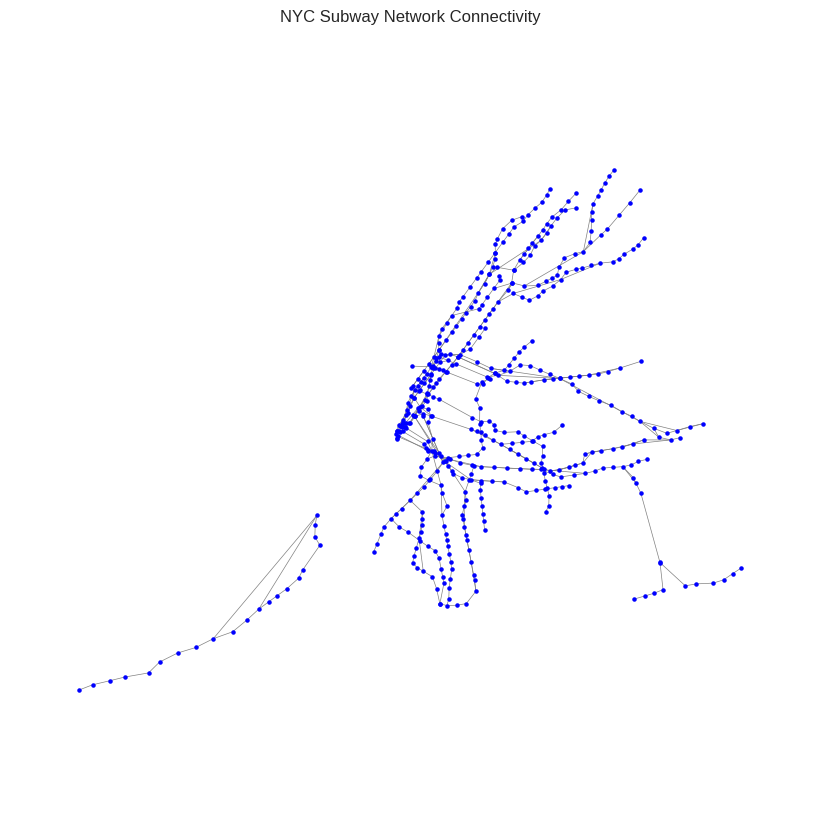

Graph visualization displayed in 0.05 seconds.


In [2]:
subway_graph: nx.Graph = load_subway_graph()
plot_subway_graph(subway_graph=subway_graph)

In [3]:
x_train: np.ndarray
x_test: np.ndarray
y_train_log: np.ndarray
y_test_log: np.ndarray
train_indices: np.ndarray
test_indices: np.ndarray
listing_coords_all: pd.Series
(
    x_train,
    x_test,
    y_train_log,
    y_test_log,
    train_indices,
    test_indices,
    listing_coords_all,
) = load_nyc_airbnb_dataset()

📥 Loading and preparing NYC Airbnb dataset...
Features being used: ['host_listings_count', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'latitude', 'longitude']
Data prepared: 17062 training samples, 4266 testing samples.


In [4]:
original_idx_to_station_map: Dict[int, Optional[str]] = (
    calculate_unified_index_to_station_map(
        subway_graph=subway_graph,
        listing_coords_all=listing_coords_all,
        max_station_dist_km=2.0,
    )
)

Extracted coordinates for 499 stations.
Pre-calculating unified index-to-station map for ALL data...
Unified map created.


In [5]:
sanity_test_path_exists_and_kernel(
    subway_graph=subway_graph,
    original_idx_to_station_map=original_idx_to_station_map,
    train_indices=train_indices,
    test_indices=test_indices,
)

🏭 Generating kernel for testing...
🔍 Searching for test point pairs...
Searching first 1000 test points against first 1000 train points...

--- Test 1: Same Station ---
Target (Test Idx 0):   Orig Idx 11051 -> Station: 632
Neighbor (Train Idx 118): Orig Idx 14146 -> Station: 632
Stations are the same. Expected score: 1.0
Kernel Output Score: 1.0000
✅ Success: Kernel output matches manual calculation.

--- Test 2: Some Distance ---
Target (Test Idx 0):   Orig Idx 11051 -> Station: 632
Neighbor (Train Idx 0): Orig Idx 12799 -> Station: L29
Distance: 16. Expected score: exp(-16/2.0) = 0.0003
Kernel Output Score: 0.0003
✅ Success: Kernel output matches manual calculation.


🎨 Visualizing kernel similarity from 'Times Sq-42 St'...
Found it! The ID for 'Times Sq-42 St' is: '127'
Applying zoom: graph radius <= 8 stops.
Found 244 nodes within radius.
Plot saved as 'subway_kernel_similarity_zoomed_8.png'.


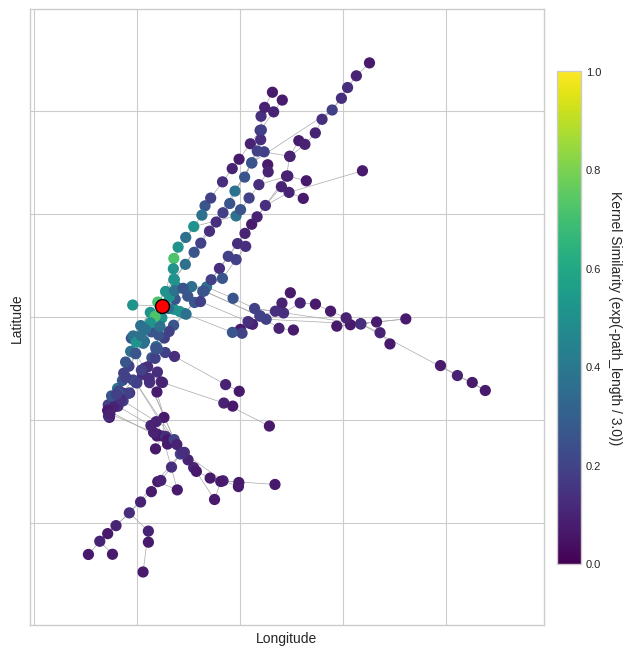

In [68]:
plot_kernel_similarity_from_reference(
    subway_graph=subway_graph,
    reference_station_id="Times Sq-42 St",
    distance_scale=3,
    save_plot=True,
    zoom_graph_radius=8
)

In [7]:
cv: int = 10
n_jobs: int = -1

In [8]:
knn_param_grid: Dict[str, List[Any]] = {
    "n_neighbors": list(range(3, 50, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
    "leaf_size": [15, 30, 60],  # this mostly affects speed, not results
}

results_knn: GridSearchCV = cv_knn(
    x_train=x_train,
    y_train_log=y_train_log,
    param_grid=knn_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_knn.best_params_

🔎 Grid searching KNeighborsRegressor...


{'leaf_size': 60, 'n_neighbors': 21, 'p': 1, 'weights': 'distance'}

In [9]:
linear_param_grid: Dict[str, List[Any]] = {
    "fit_intercept": [True, False],
    "positive": [False, True],  # enforce non-negative coefficients
}

results_linear: GridSearchCV = cv_linear(
    x_train=x_train,
    y_train_log=y_train_log,
    param_grid=linear_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_linear.best_params_

🔎 Grid searching LinearRegression...


{'fit_intercept': True, 'positive': False}

In [10]:
poly_ridge_pipeline_param_grid: Dict[str, List[Any]] = {
    "poly__degree": [2, 3],
    "poly__interaction_only": [False, True],
    "ridge__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    results_poly_ridge: GridSearchCV = cv_poly_ridge(
        x_train=x_train,
        y_train_log=y_train_log,
        param_grid=poly_ridge_pipeline_param_grid,
        cv=cv,
        n_jobs=n_jobs,
    )

results_poly_ridge.best_params_

🔎 Grid searching Quadratic (Polynomial + Ridge)...


{'poly__degree': 3, 'poly__interaction_only': False, 'ridge__alpha': 100.0}

In [51]:
lpr_param_grid: List[Dict[str, List[Any]]] = [
    # --- Grid 1: Testing Minkowski metric (p=1 and p=2) ---
    {
        "size_neighborhood": list(range(7, 31, 2)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["minkowski"],
        "metric_x_params": [{"p": 1}, {"p": 2}],
        "kr": ["none"],  # standard LPR
    },
    # --- Grid 2: Testing Mahalanobis metric ---
    {
        "size_neighborhood": list(range(7, 31, 2)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["mahalanobis"],
        "metric_x_params": [None],  # Mahalanobis takes no params
        "kr": ["none"],  # standard LPR
    },
]

results_lpr: GridSearchCV = cv_lpr(
    x_train=x_train,
    y_train_log=y_train_log,
    param_grid=lpr_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_lpr.best_params_

🔎 Grid searching LPR...


{'degree': 0,
 'kp': <function rsklpr.kernels.tricube_normalized_metric(_: numpy.ndarray, __: numpy.ndarray, u: numpy.ndarray, ___: int, ____: numpy.ndarray) -> numpy.ndarray>,
 'kr': 'none',
 'metric_x': 'mahalanobis',
 'metric_x_params': None,
 'size_neighborhood': 19}

In [52]:
rsklpr_param_grid: List[Dict[str, Any]] = [
    # --- Grid 1: Testing Minkowski metric (p=1 and p=2) ---
    {
        "size_neighborhood": list(range(7, 31, 2)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["minkowski"],
        "metric_x_params": [{"p": 1}, {"p": 2}],
        "kr": ["conden", "joint"],  # RSKLPR
    },
    # --- Grid 2: Testing Mahalanobis metric ---
    {
        "size_neighborhood": list(range(7, 31, 2)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["mahalanobis"],
        "metric_x_params": [None],  # Mahalanobis takes no params
        "kr": ["conden", "joint"],  # RSKLPR
    },
]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    results_rsklpr: GridSearchCV = cv_rsklpr(
        x_train=x_train,
        y_train_log=y_train_log,
        param_grid=rsklpr_param_grid,
        cv=cv,
        n_jobs=n_jobs,
    )

results_rsklpr.best_params_

🔎 Grid searching RSKLPR...


{'degree': 0,
 'kp': <function rsklpr.kernels.tricube_normalized_metric(_: numpy.ndarray, __: numpy.ndarray, u: numpy.ndarray, ___: int, ____: numpy.ndarray) -> numpy.ndarray>,
 'kr': 'conden',
 'metric_x': 'mahalanobis',
 'metric_x_params': None,
 'size_neighborhood': 19}

In [53]:
grclpr_subway_params_grid: Dict[str, List[Any]] = {
    "size_neighborhood": [12],
    "degree": [0],
    "metric_x": ["minkowski"],
    "metric_x_params": [{"p": 1}],
    "kr": ["conden"],
    "distance_scale": [2.0],
}


with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    results_grclpr_subway: GridSearchCV = cv_grclpr_subway(
        x_train=x_train,
        y_train_log=y_train_log,
        train_indices=train_indices,
        subway_graph=subway_graph,
        original_idx_to_station_map=original_idx_to_station_map,
        param_grid=grclpr_subway_params_grid,
        cv=cv,
        n_jobs=n_jobs,
    )

results_grclpr_subway.best_params_

📦 Packing original indices into X_train for GRC-LPR Subway...
Original x_train shape: (17062, 10)
New X_train_with_indices shape: (17062, 11)
⚙️ Defining model and search grid for GRC-LPR Subway...
🚀 Starting GridSearchCV for GRC-LPR Subway...


{'degree': 0,
 'distance_scale': 2.0,
 'kr': 'conden',
 'metric_x': 'minkowski',
 'metric_x_params': {'p': 1},
 'size_neighborhood': 12}


📊 Displaying results for all evaluated models...

--- Processing: knn ---
Best Parameters: {'leaf_size': 60, 'n_neighbors': 21, 'p': 1, 'weights': 'distance'}
Best CV Score (neg_mean_squared_error): -0.2662
Test Set R² (Price):   0.8830
Test Set MAE (Price):  $200.63
Test Set RMSE (Price): $1608.30

--- Processing: linear ---
Best Parameters: {'fit_intercept': True, 'positive': False}
Best CV Score (neg_mean_squared_error): -0.4893
Test Set R² (Price):   0.5452
Test Set MAE (Price):  $462.18
Test Set RMSE (Price): $3171.05

--- Processing: poly_ridge ---
Best Parameters: {'poly__degree': 3, 'poly__interaction_only': False, 'ridge__alpha': 100.0}
Best CV Score (neg_mean_squared_error): -0.3459
Test Set R² (Price):   0.7087
Test Set MAE (Price):  $354.34
Test Set RMSE (Price): $2537.67

--- Processing: lpr ---
Best Parameters: {'degree': 0, 'kp': <function tricube_normalized_metric at 0x79a9ecea3ce0>, 'kr': 'none', 'metric_x': 'mahalanobis', 'metric_x_params': None, 'size_neighborhood':

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Test Set R² (Price):   0.9354
Test Set MAE (Price):  $188.53
Test Set RMSE (Price): $1195.20


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


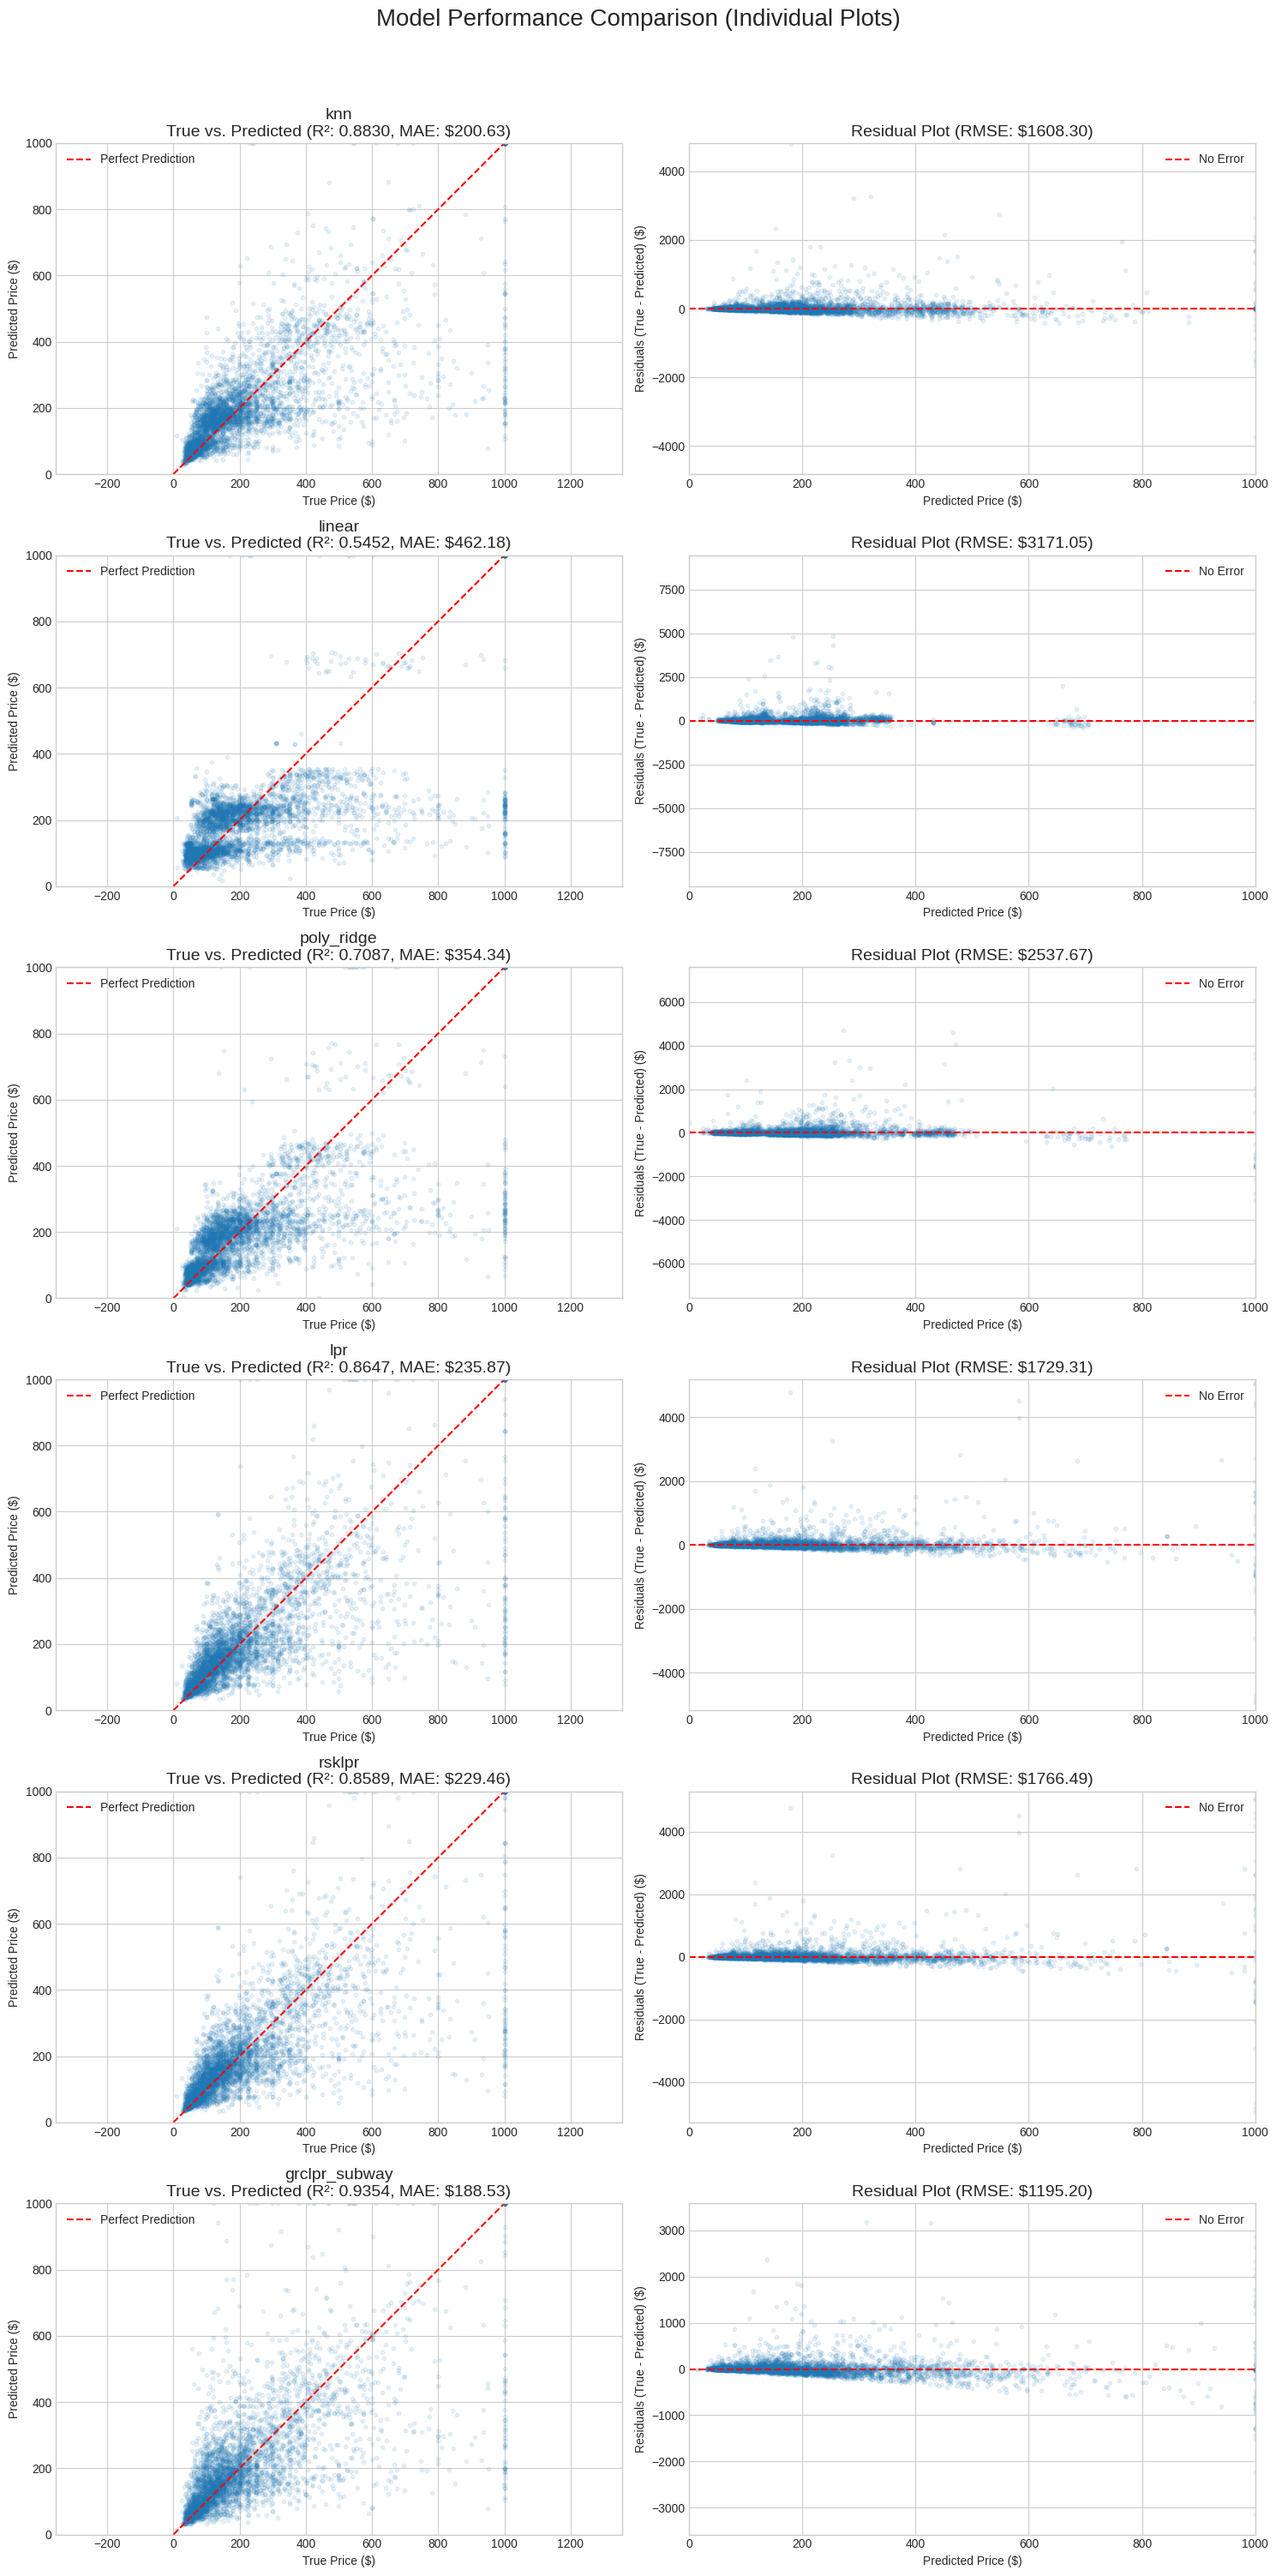

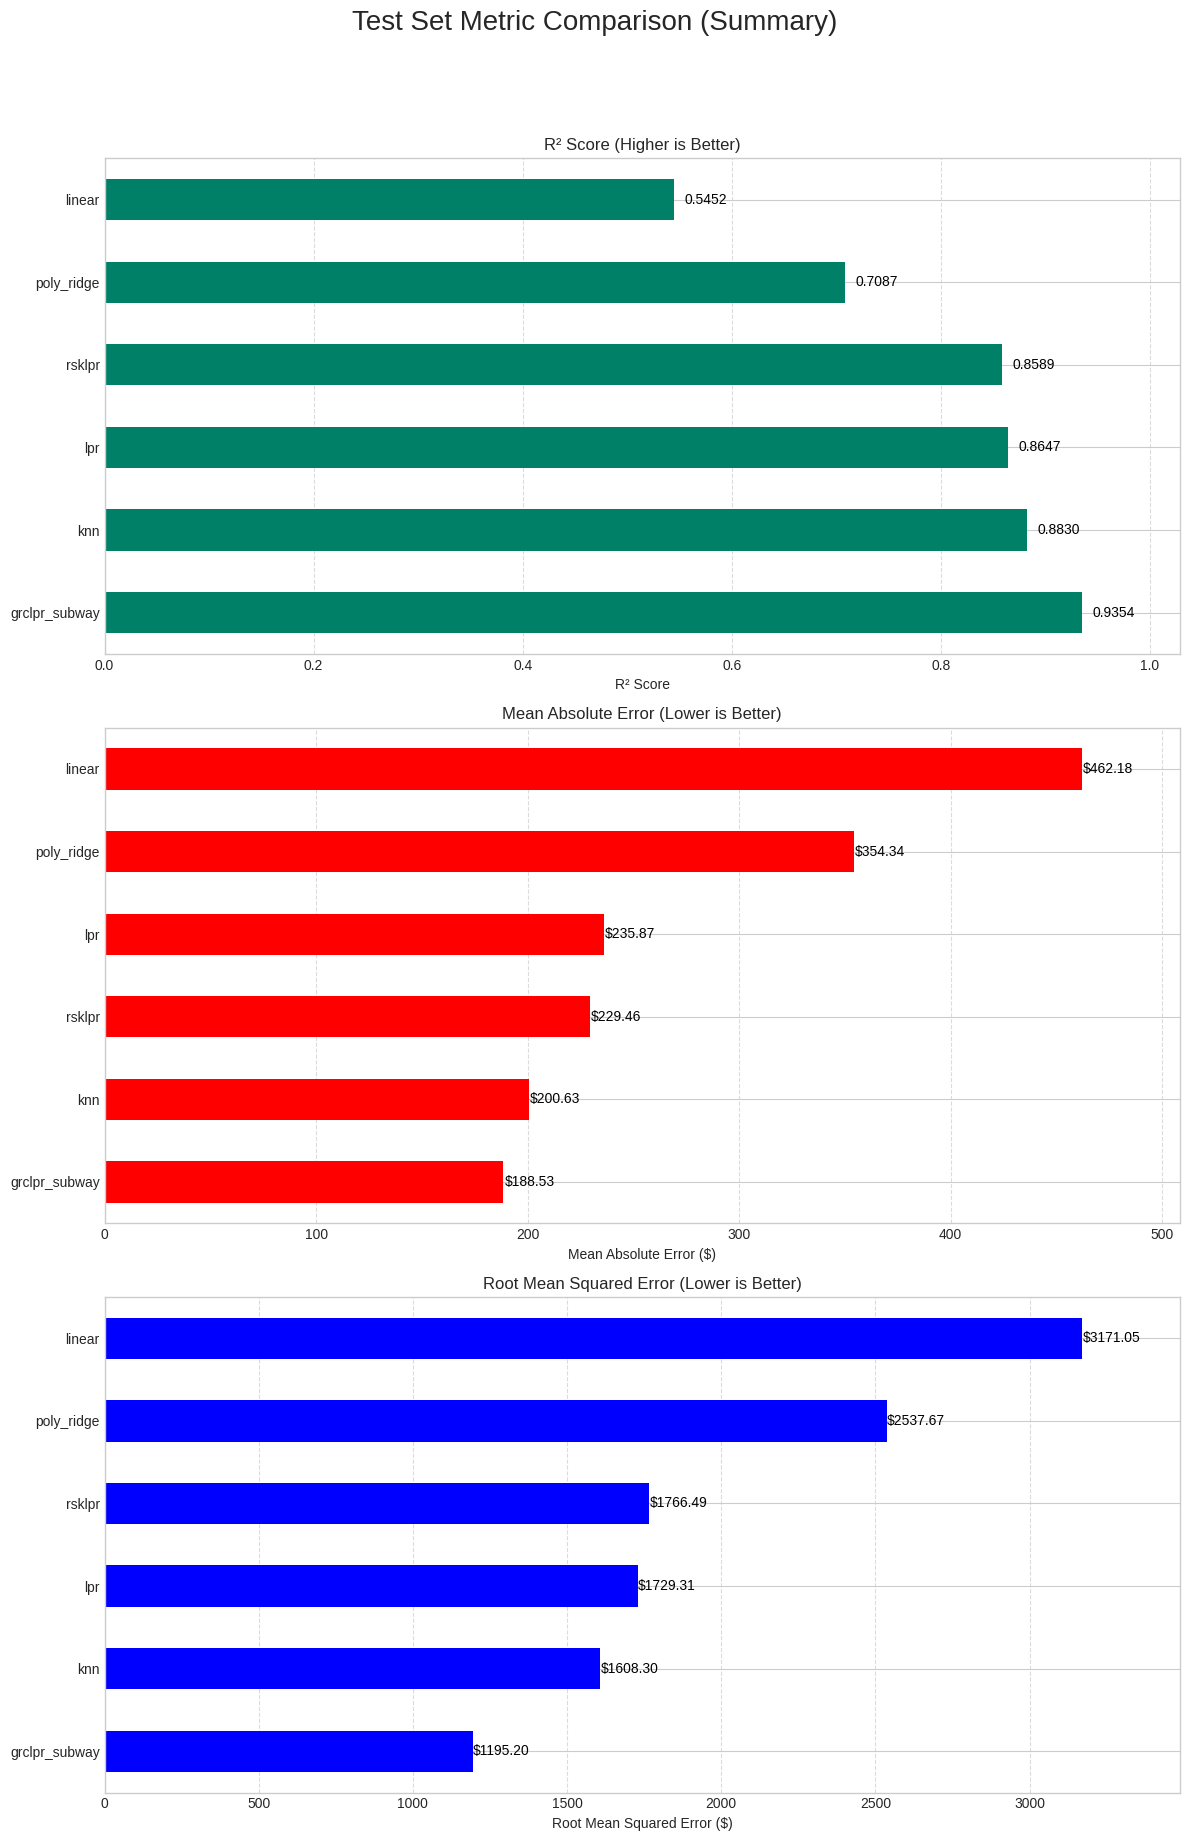

In [54]:
display_model_results(
    grid_search_results={
        "knn": results_knn,
        "linear": results_linear,
        "poly_ridge": results_poly_ridge,
        "lpr": results_lpr,
        "rsklpr": results_rsklpr,
        "grclpr_subway": results_grclpr_subway,
    },
    x_test=x_test,
    y_test_log=y_test_log,
    test_indices=test_indices,
)